# $\color{#dda}{\text{Héctor Alonso Heredia Pérez}}$
# $\color{#dda}{\text{César Adrián Santos Santacruz}}$
# $\color{#dda}{\text{José García Fernández del Valle}}$

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_regression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## $\color{#dda}{\text{1: Tomamos el dataset}}$

In [87]:
path = '.'

df = pd.read_csv('db_pap3.csv')

In [88]:
df

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,768805383,1,45,M,3,High School,Married,5833.333333333333,Blue,39,5,1,3,12691.0,777,1144,42
1,818770008,1,49,F,5,Graduate,Single,1666.6666666666667,Blue,44,6,1,2,8256.0,864,1291,33
2,713982108,1,51,M,3,Graduate,Married,8333.333333333334,Blue,36,4,1,0,3418.0,0,1887,20
3,769911858,1,40,F,4,High School,Unknown,1666.6666666666667,Blue,34,3,4,1,3313.0,2517,1171,20
4,709106358,1,40,M,3,Uneducated,Married,5833.333333333333,Blue,21,5,1,0,4716.0,0,816,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,1,50,M,2,Graduate,Single,4166.666666666667,Blue,40,3,2,3,4003.0,1851,15476,117
10123,710638233,0,41,M,2,Unknown,Divorced,4166.666666666667,Blue,25,4,2,3,4277.0,2186,8764,69
10124,716506083,0,44,F,1,High School,Married,1666.6666666666667,Blue,36,5,3,4,5409.0,0,10291,60
10125,717406983,0,30,M,2,Graduate,Unknown,4166.666666666667,Blue,36,4,3,3,5281.0,0,8395,62


## $\color{#dda}{\text{2. Análisis Descriptivo y Agrupado de los Datos}}$

El dataset tiene 10,127 registros y 17 columnas, hay tanto variables numéricas como categóricas. La variable objetivo es client_stayed, donde un valor de 1 indica que el cliente se quedó con el banco y un valor de 0 indica que el cliente abandonó el banco.

Las columnas incluyen información demográfica del cliente, detalles sobre sus interacciones con el banco y características de su crédito. A continuación, realizamos un análisis descriptivo detallado de las variables.

In [89]:
cols = df.columns
'''
for i in range(cols.size):
    print(cols[i])
    # print(df[cols[i]])
'''
for i in range(cols.size):
    print(f'{cols[i]} -> {df[cols[i]].unique()}')

clientnum -> [768805383 818770008 713982108 ... 716506083 717406983 714337233]
client_stayed -> [1 0]
customer_age -> [45 49 51 40 44 32 37 48 42 65 56 35 57 41 61 47 62 54 59 63 53 58 55 66
 50 38 46 52 39 43 64 68 67 60 73 70 36 34 33 26 31 29 30 28 27]
gender -> ['M' 'F']
dependent_count -> [3 5 4 2 0 1]
education_level -> ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
marital_status -> ['Married' 'Single' 'Unknown' 'Divorced']
income_category -> ['5833.333333333333' '1666.6666666666667' '8333.333333333334'
 '4166.666666666667' '10000.0' 'Unknown']
card_category -> ['Blue' 'Gold' 'Silver' 'Platinum']
months_on_book -> [39 44 36 34 21 46 27 31 54 30 48 37 56 42 49 33 28 38 41 43 45 52 40 50
 35 47 32 20 29 25 53 24 55 23 22 26 13 51 19 15 17 18 16 14]
total_relationship_count -> [5 6 4 3 2 1]
months_inactive_12_mon -> [1 4 2 3 6 0 5]
contacts_count_12_mon -> [3 2 0 1 4 5 6]
credit_limit -> [12691.  8256.  3418. ...  5409.  5281. 10388.]
total

### $\color{#dda}{\text{2.1 Verificación de Datos Faltantes y Tipos de Datos}}$

Vemos que a pesar de que no hay nulos, hay valores "Unknown", así que tendremos que hacer algo al respecto. Lo más sencillo será tratarlos como si fueran NAs

In [90]:
missing_values = df.isnull().sum()

unknowns_count = df.apply(lambda col: (col == 'Unknown').sum())

data_types = df.dtypes

summary_stats = df.describe()

In [91]:
missing_values

clientnum                   0
client_stayed               0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
total_trans_amt             0
total_trans_ct              0
dtype: int64

In [92]:
unknowns_count

clientnum                      0
client_stayed                  0
customer_age                   0
gender                         0
dependent_count                0
education_level             1519
marital_status               749
income_category             1112
card_category                  0
months_on_book                 0
total_relationship_count       0
months_inactive_12_mon         0
contacts_count_12_mon          0
credit_limit                   0
total_revolving_bal            0
total_trans_amt                0
total_trans_ct                 0
dtype: int64

In [93]:
data_types

clientnum                     int64
client_stayed                 int64
customer_age                  int64
gender                       object
dependent_count               int64
education_level              object
marital_status               object
income_category              object
card_category                object
months_on_book                int64
total_relationship_count      int64
months_inactive_12_mon        int64
contacts_count_12_mon         int64
credit_limit                float64
total_revolving_bal           int64
total_trans_amt               int64
total_trans_ct                int64
dtype: object

In [94]:
summary_stats

,clientnum,client_stayed,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,0.839340,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,4404.086304,64.858695
std,3.690378e+07,0.367235,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,3397.129254,23.472570
min,7.080821e+08,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,510.000000,10.000000
25%,7.130368e+08,1.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,2155.500000,45.000000
50%,7.179264e+08,1.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3899.000000,67.000000
75%,7.731435e+08,1.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,4741.000000,81.000000
max,8.283431e+08,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,18484.000000,139.000000


### $\color{#dda}{\text{2.2 Distribución de Variables Numéricas}}$

Las distribuciones discretas se ven con cierta normalidad, algunas de las siguientes, a pesar de que son numéricas, no se pueden considerar como tal porque son categóricas, eso se resolverá más adelante pero igual nos sirve ver cómo están distribuidas.

<Figure size 1200x800 with 0 Axes>

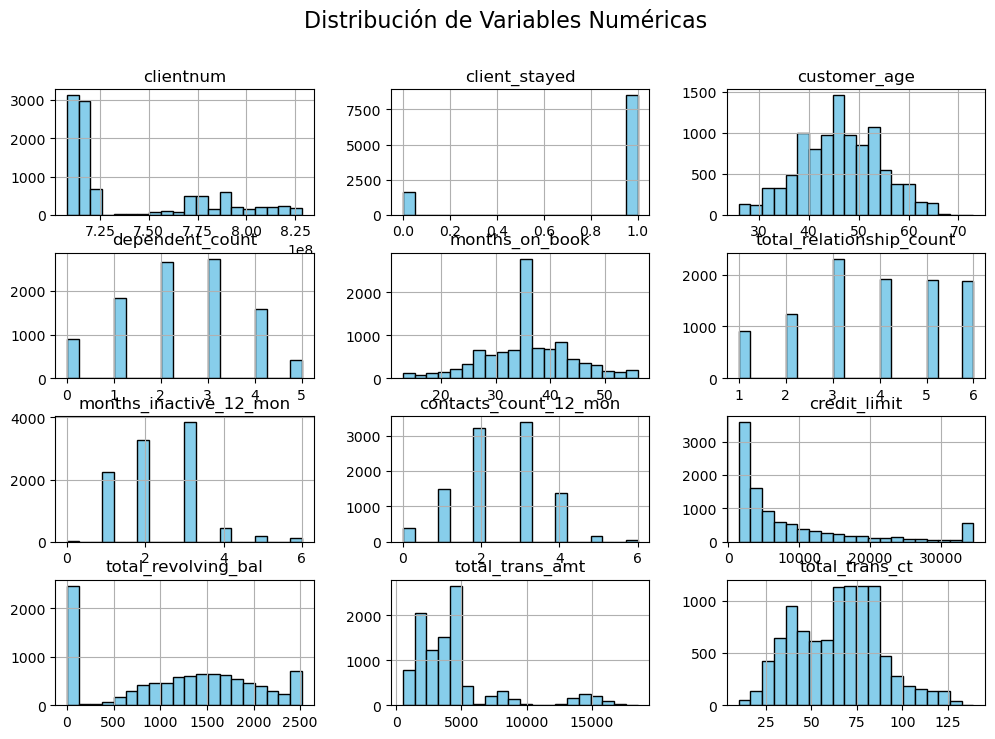

In [95]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# graficamos distribuciones de variables numéricas
plt.figure(figsize=(12, 8))
df[num_cols].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.show()

### $\color{#dda}{\text{2.3 Correlación entre Variables Numéricas}}$

Realizaremos análisis cruzados entre variables numéricas y categóricas para explorar cómo interactúan entre sí y con la variable objetivo client_stayed. Vamos a calcular la matriz de correlación para las variables numéricas y observar si hay relaciones significativas.

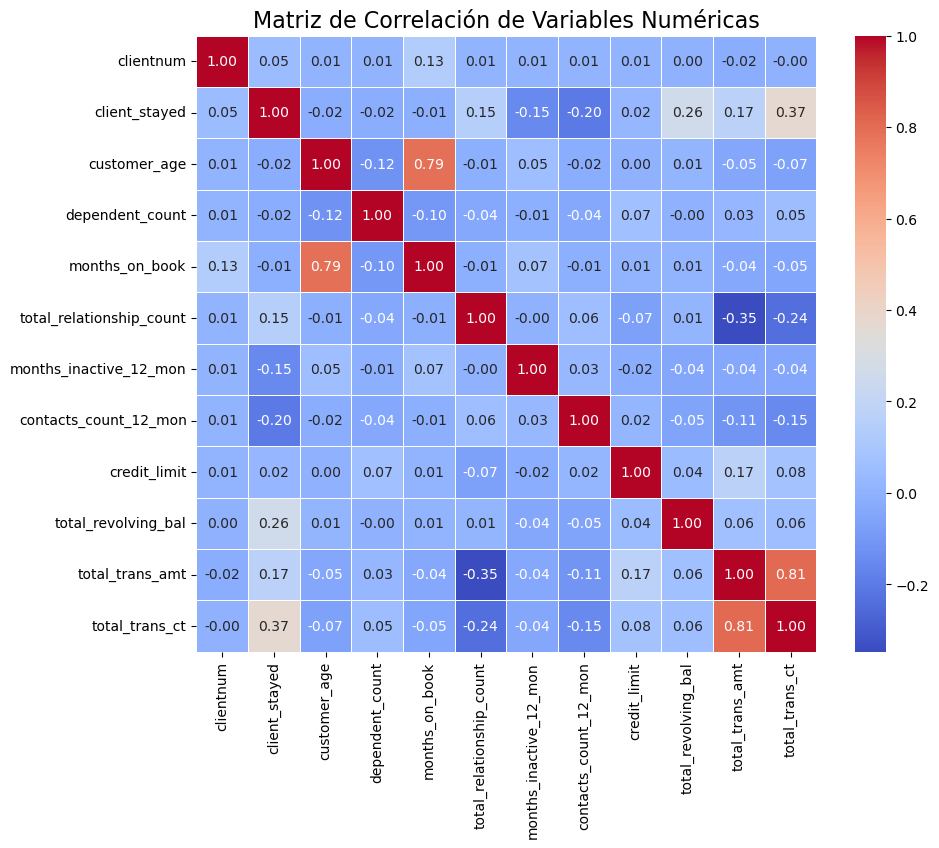

In [96]:
# matriz de correl
corr_matrix = df[num_cols].corr()

# graficamos mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16)
plt.show()

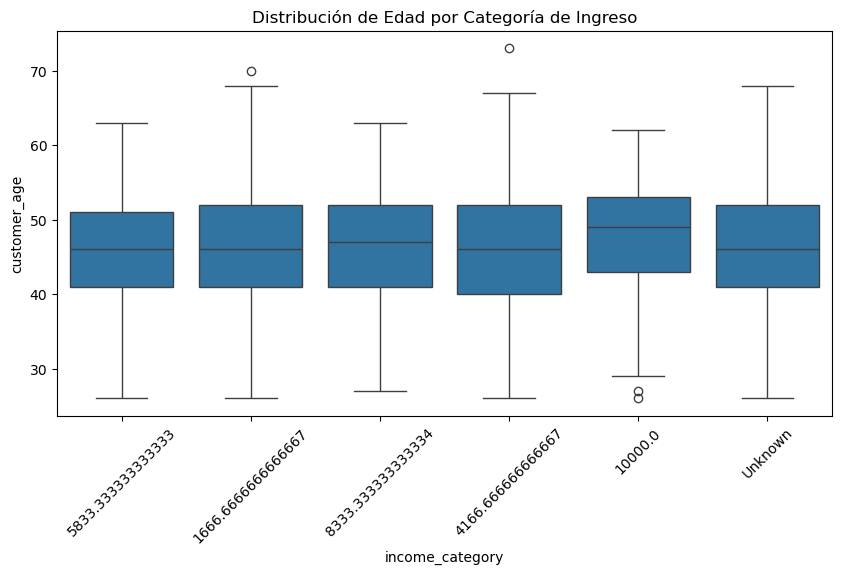

In [97]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="income_category", y="customer_age")
plt.title("Distribución de Edad por Categoría de Ingreso")
plt.xticks(rotation=45)
plt.show()

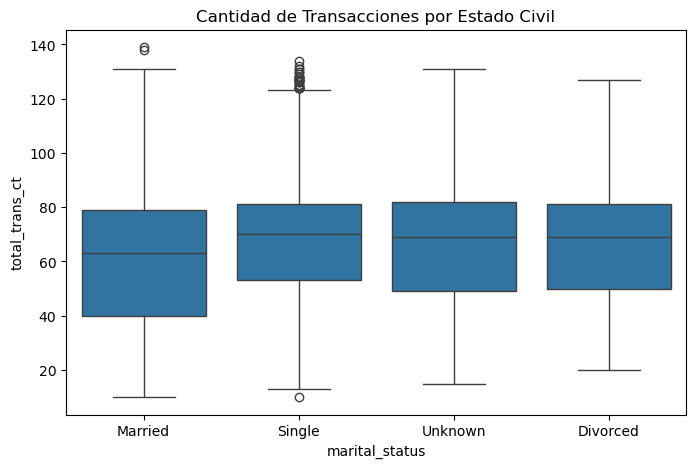

In [98]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="marital_status", y="total_trans_ct")
plt.title("Cantidad de Transacciones por Estado Civil")
plt.show()

## $\color{#dda}{\text{3. Preprocesamiento de los Datos}}$

### $\color{#dda}{\text{3.1 Limpieza y Estandarización}}$

In [99]:
# checamos valores únicos en categóricas
cat_values = {col: df[col].unique() for col in cat_cols}

# cambiamos unknown por nulos para que valga la pena el rellenado
df.replace("Unknown", pd.NA, inplace=True)

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,0.802878,0.437506,-0.165406,M,0.503368,High School,Married,5833.333333333333,Blue,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,-0.959707,-0.973895
1,2.156861,0.437506,0.333570,F,2.043199,Graduate,Single,1666.6666666666667,Blue,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.916433,-1.357340
2,-0.682769,0.437506,0.583058,M,0.503368,Graduate,Married,8333.333333333334,Blue,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.740982,-1.911206
3,0.832862,0.437506,-0.789126,F,1.273283,High School,<NA>,1666.6666666666667,Blue,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.951758,-1.911206
4,-0.814896,0.437506,-0.789126,M,0.503368,Uneducated,Married,5833.333333333333,Blue,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-1.056263,-1.570365


### $\color{#dda}{\text{3.2 Rellenar Información Faltante}}$

##### Explicar el porqué del método elegido.
Para no alterar la distribución de los datos, rellenamos numéricos con la media y categóricos con la moda 

##### Evaluar los impactos en el conjunto de datos del método elegido. Responder:
    a) ¿La variable después de rellenar cambió su distribución de alguna forma?
    -> Sí, aumentó la curtosis por la concentración de los datos hacia el centro.
    b) ¿Cambiaron estadísticos como el promedio y la desviación estándar de la variable?
    -> El promedio se mantuvo porque rellenamos con la media, pero la desvest se redujo por lo mismo.
    c) ¿Cambió la correlación de la variable con la variable objetivo?
    -> Parece que no, si lo hizo fue insignificante

In [100]:
# rellenamos num_cols con la media
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# rellenamos cat_cols con la moda
df[cat_cols] = df[cat_cols].apply(lambda col: col.fillna(col.mode()[0]))

# confirmamos
missing_after_fill = df.isnull().sum()
missing_after_fill


clientnum                   0
client_stayed               0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
total_trans_amt             0
total_trans_ct              0
dtype: int64

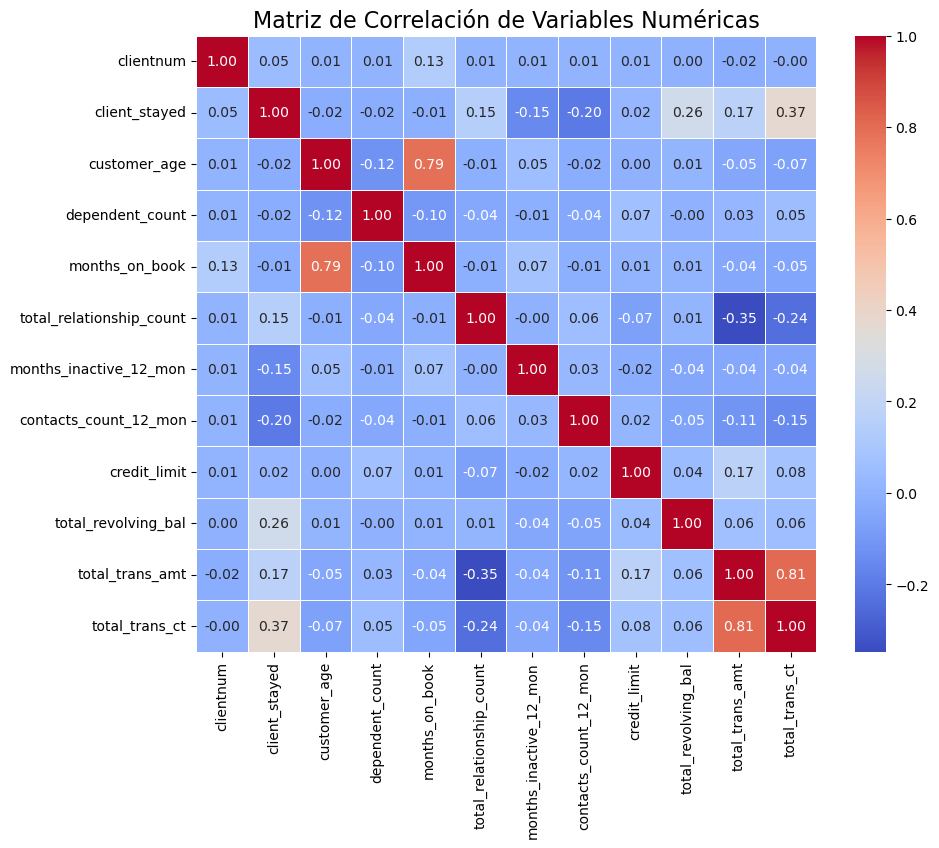

In [101]:
corr_matrix = df[num_cols].corr()

# graficamos mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16)
plt.show()

## $\color{#dda}{\text{4. Generación de Nuevas Variables (Feature Engineering)}}$

### $\color{#dda}{\text{4.1 Crear Nuevas Variables (como si no tuviéramos suficientes) (nunca lo son)}}$

---

## 1. `age_income_ratio`

**Descripción:**  
Relaciona la edad del cliente con su categoría de ingresos estimados. Permite identificar perfiles con alta o baja capacidad económica relativa a su etapa de vida.

**Hipótesis:**  
Clientes jóvenes con altos ingresos podrían representar una mayor probabilidad de permanencia debido a su potencial financiero a largo plazo.

**Comportamiento observado:**  
Se identifican diferencias en la proporción según el estado del cliente. Aquellos que permanecen tienden a tener ratios más estables, indicando un equilibrio entre edad e ingresos.

---

## 2. `credit_inactivity_ratio`

**Descripción:**  
Calcula la proporción entre el número de meses de inactividad y el total de meses que el cliente ha estado activo con el banco. Mide el grado de desuso del producto financiero.

**Hipótesis:**  
Un mayor porcentaje de inactividad se asocia con una mayor probabilidad de abandono del banco.

**Comportamiento observado:**  
Los clientes que han dejado de ser activos presentan valores significativamente más altos en esta variable, lo que valida su utilidad como indicador temprano de abandono.

---

## 3. `relationship_level`

**Descripción:**  
Variable ordinal derivada del número de productos que el cliente tiene con el banco. Representa el nivel de compromiso del cliente.

**Hipótesis:**  
A mayor número de productos, menor probabilidad de cancelación.

**Comportamiento observado:**  
Los clientes con un nivel de relación más alto muestran tasas de permanencia superiores, lo que sugiere una correlación positiva entre el nivel de compromiso y la retención.

---

## 4. `credit_to_balance_ratio`

**Descripción:**  
Mide la proporción entre el límite de crédito y el balance pendiente del cliente. Permite identificar cuán endeudado está en relación con su capacidad crediticia.

**Hipótesis:**  
Clientes con ratios bajos (más endeudados) podrían estar en situaciones de estrés financiero y tener mayor propensión a abandonar.

**Comportamiento observado:**  
Se observa una tendencia donde clientes con mayor equilibrio entre límite y deuda presentan una mayor probabilidad de permanencia.

---

## 5. `trans_per_month`

**Descripción:**  
Promedio mensual de transacciones realizadas por el cliente con su instrumento crediticio.

**Hipótesis:**  
Una mayor frecuencia de uso indica un vínculo más fuerte con el producto, lo cual reduce la probabilidad de abandono.

**Comportamiento observado:**  
Los clientes que permanecen realizan más transacciones mensuales en promedio que aquellos que se van, lo cual apoya la hipótesis de comportamiento leal.

---

## 6. `mtrans_ct`

**Descripción:**  
Dinero por transacción

**Hipótesis:**  
División de dinero por al mes entre transacción.

**Comportamiento observado:**  
Según parece da una buena idea de qué tan estable es el flujo económico de un cliente.



In [102]:
df['income_category'] = pd.to_numeric(df['income_category'], errors='coerce')

# creamos nuevas variables (sumamos 1 para evitar división por cero)
df['age_income_ratio'] = df['customer_age'] / (df['income_category']+1)
df['credit_inactivity_ratio'] = df['credit_limit'] / (df['months_inactive_12_mon']+1)
df['credit_to_balance_ratio'] = df['credit_limit'] / (df['total_revolving_bal']+1)
df['trans_per_month'] = df['total_trans_ct'] / (df['months_on_book']+1)
df['mtrans_ct'] = df['total_trans_amt'] / (df['total_trans_ct']+1)
def relationship_level(x):
    if x <= 2:
        return 'low'
    elif x <= 4:
        return 'medium'
    else:
        return 'high'

df['relationship_level'] = df['total_relationship_count'].apply(relationship_level)

df[['age_income_ratio', 'credit_to_balance_ratio','credit_inactivity_ratio', 'relationship_level', 'trans_per_month']].head()


,age_income_ratio,credit_to_balance_ratio,credit_inactivity_ratio,relationship_level,trans_per_month
0,-0.000028,0.848159,-1.365248,low,-0.703366
1,0.000200,-0.065316,0.126451,low,-0.675054
2,0.000070,1.344000,1.753698,low,-1.894225
3,-0.000473,-0.219880,-0.221562,low,-2.519628
4,-0.000135,1.009415,1.317120,low,1.806435


### $\color{#dda}{\text{4.2 Hipótesis y Análisis de las Nuevas Variables}}$

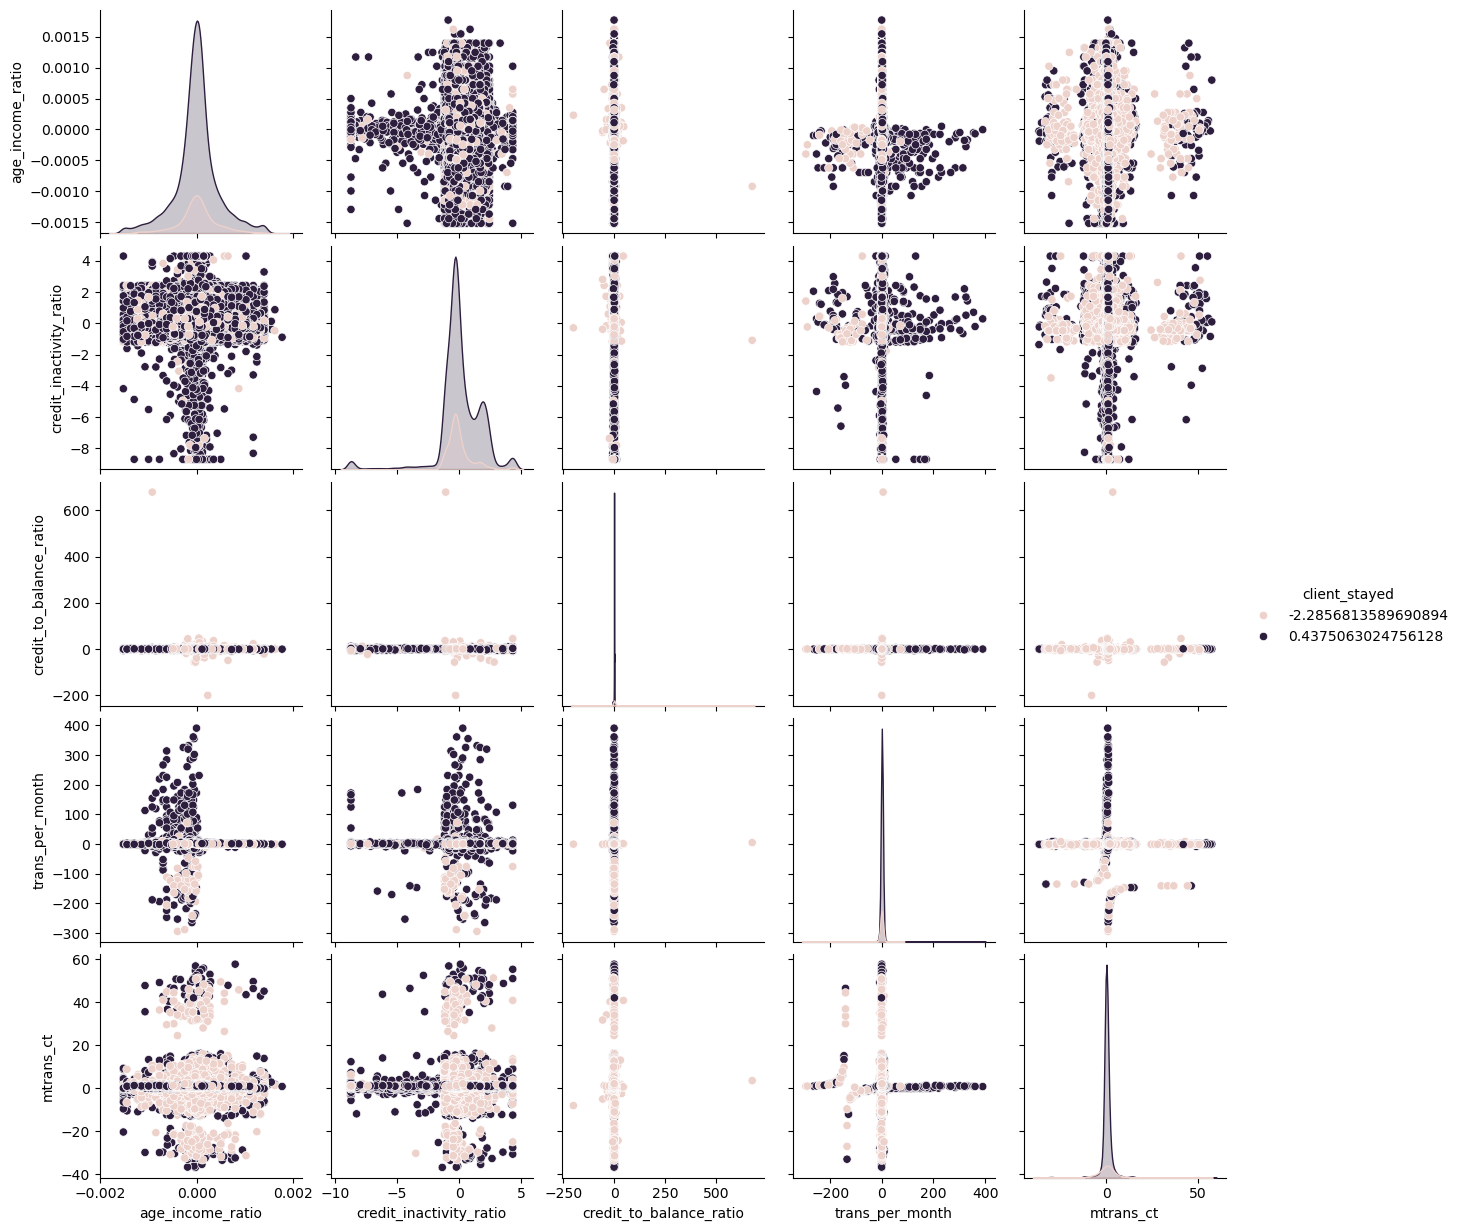

In [103]:
# analizar cómo las nuevas variables se relacionan con la variable de respuesta
# también la relación entre la variable 'client_stayed' y las nuevas variables

sns.pairplot(
    df[['client_stayed', 
        'age_income_ratio', 
        'credit_inactivity_ratio', 
        'relationship_level', 
        'credit_to_balance_ratio', 
        'trans_per_month',
        'mtrans_ct']], 
    hue="client_stayed",

)
plt.show()


# Conclusión del análisis de variables

Si bien no todos los gráficos generados permitieron observar relaciones claras entre las variables derivadas y la variable objetivo (`client_stayed`), se identificaron patrones consistentes y relevantes en algunas de ellas. En particular, la variable `trans_per_month` mostró un comportamiento notable al compararse con la retención de cliente sexplicativo significativo.


## $\color{#dda}{\text{5. Selección de Variables}}$

### $\color{#dda}{\text{5.1 Selección con Correlación}}$

In [104]:
# 1. Definimos X e y
X = df.drop(columns=['clientnum', 'client_stayed'])
y = df['client_stayed'].astype(int)

# 2. Columnas numéricas y categóricas
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# 3. Preprocesador
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)  # para evitar colinealidad
])

# 4. Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 5. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Entrenamiento
pipeline.fit(X_train, y_train)

# 7. Predicciones
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

### $\color{#dda}{\text{5.2 Selección con Regresión Logística}}$

In [105]:
# Obtener los nombres de las columnas transformadas
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

# Combinar numéricas y categóricas codificadas
feature_names = np.concatenate([num_cols, cat_feature_names])

# Obtener coeficientes del modelo
coef = pipeline.named_steps['classifier'].coef_[0]
intercept = pipeline.named_steps['classifier'].intercept_[0]

# Mostrar en tabla ordenada
coef_table = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coef
}).sort_values(by='Coeficiente', key=np.abs, ascending=False)

print("Intercepto:", intercept)
print("\nCoeficientes ordenados por impacto:\n")
print(coef_table)


Intercepto: 1.7401091733170453

Coeficientes ordenados por impacto:

                          Feature   Coeficiente
10                 total_trans_ct  2.692546e+00
9                 total_trans_amt -1.475667e+00
22         marital_status_Married  8.922738e-01
8             total_revolving_bal  7.835499e-01
4        total_relationship_count  7.090653e-01
16                       gender_M  6.566859e-01
6           contacts_count_12_mon -5.728424e-01
5          months_inactive_12_mon -4.971712e-01
21     education_level_Uneducated  3.743103e-01
23          marital_status_Single  3.587212e-01
19    education_level_High School  3.229441e-01
1                 dependent_count -1.969236e-01
18       education_level_Graduate  1.245793e-01
3                  months_on_book  1.230926e-01
26           card_category_Silver  1.158533e-01
24             card_category_Gold -1.012717e-01
0                    customer_age -8.126464e-02
20  education_level_Post-Graduate  3.928308e-02
12        credit_in

In [106]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8899308983218164

Reporte de clasificación:
              precision    recall  f1-score   support

          -2       0.74      0.49      0.59       327
           0       0.91      0.97      0.94      1699

    accuracy                           0.89      2026
   macro avg       0.82      0.73      0.76      2026
weighted avg       0.88      0.89      0.88      2026


Matriz de confusión:
[[ 161  166]
 [  57 1642]]


## $\color{#dda}{\text{Evaluación}}$

---

### $\color{#dda}{\text{Accuracy}}$  
**0.8899**

---

### $\color{#dda}{\text{Reporte de Clasificación}}$

| Clase | Precision | Recall | F1-score | Soporte |
|-------|-----------|--------|----------|---------|
| **-2** | 0.74      | 0.49   | 0.59     | 327     |
| **0**  | 0.91      | 0.97   | 0.94     | 1699    |

**Accuracy global**: 0.89  
**Macro promedio**: Precision: 0.82 | Recall: 0.73 | F1-score: 0.76  
**Promedio ponderado**: Precision: 0.88 | Recall: 0.89 | F1-score: 0.88

---

### $\color{#dda}{\text{Matriz de Confusión}}$

\begin{bmatrix}
\color{#6d6}{161} & \color{#d66}{166} \\
\color{#d66}{57} & \color{#6d6}{1642}
\end{bmatrix}


## $\color{#dda}{\text{6. Respuestas a las Preguntas}}$

- **¿Cómo se implementó el método utilizado?**
    - El análisis de correlación se implementó utilizando la función `corr()` de pandas. Para la regresión logística, se utilizó la clase `LogisticRegression` de scikit-learn.

- **¿Por qué se escogió este método?**
    - El análisis de correlación proporciona una forma rápida de identificar qué variables tienen una relación lineal con la variable objetivo. La regresión logística nos permite obtener los coeficientes de las variables predictoras, lo que nos ayuda a identificar la importancia relativa de cada una.

- **¿Qué variables se van a seleccionar con el método?**
    - Aquellas con coeficientes significativos y que presentan un alto impacto en la predicción del resultado, se puede apreciar en las siguientes:

| Nº  | Variable                    | Coeficiente     |
|-----|-----------------------------|-----------------|
| 10  | total_trans_ct              | 2.692546        |
| 9   | total_trans_amt             | -1.475667       |
| 22  | marital_status_Married      | 0.892274        |
| 8   | total_revolving_bal         | 0.783550        |
| 4   | total_relationship_count    | 0.709065        |
| 16  | gender_M                    | 0.656686        |

- **¿Cómo puedo demostrar que las variables elegidas son mejores que las no elegidas?**
    - Se puede demostrar mediante la comparación de métricas de rendimiento, como la precisión o el AUC de la regresión logística con y sin las variables seleccionadas, también con R2.

- **¿Algunas de las variables generadas con el punto b quedaron elegidas? ¿Por qué?**
    - No, algunas tuvieron pésimo rendimiento, no estamos seguros de por qué pero es probable que tengamos que generar otro tipo de variables, aunque experimentamos con varias, ninguna tuvo el impacto que habríamos querido.